In [3]:
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams["font.size"] = 14

from sk_utils import Utils as u
from sk_retina_encoders import RetinalGanglionCellMosaic as RGCmodel
from sk_retina_encoders import Retina

In [4]:
u.check_gpus()

GPUs present?	True	1
Device 0: NVIDIA RTX 6000 Ada Generation


In [5]:
all_params = u.read_params("params.yaml")
on_parasol_params = all_params["ON_Parasol"]
off_parasol_params = all_params["OFF_Parasol"]
on_midget_params = all_params["ON_Midget"]
off_midget_params = all_params["OFF_Midget"]
video_params = all_params["video_parameters"]

{'fps': 30.000011135861595, 'width': 1920, 'height': 1080, 'total_frames': 898}


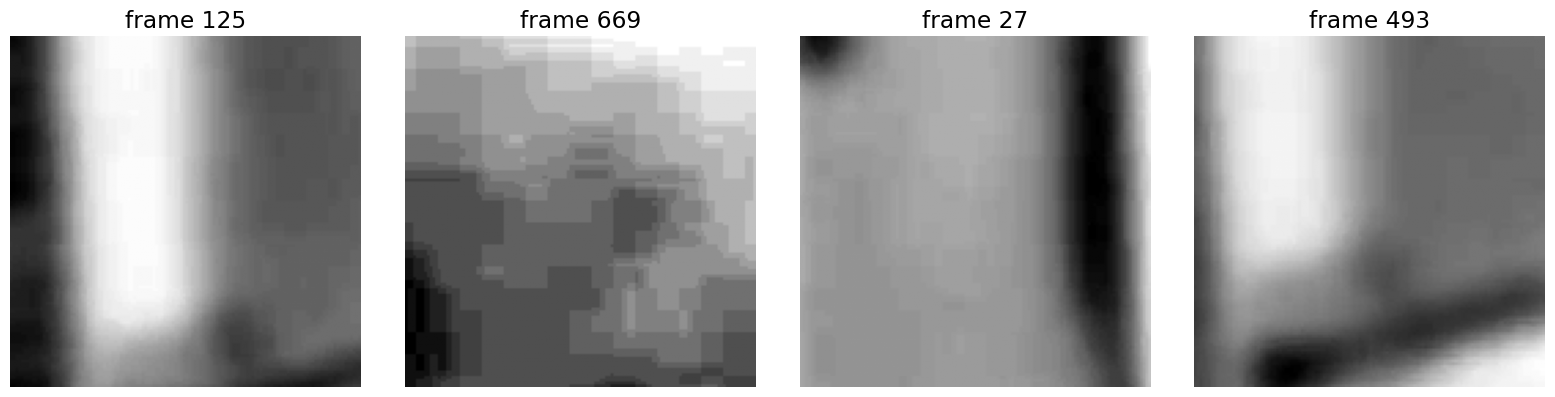

In [6]:
video, fps = u.read_video("lnp_naturalmovies/Video_2.mp4")
print(fps)

# let's crop (512, 512) patches
video_patch = np.array([f[500:500+video_params["frame_shape"][0], 500:500+video_params["frame_shape"][1]] for f in video])

# just visualize a few frames
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
frames = np.random.uniform(0, len(video_patch), 4).astype(np.uint32)

for i,f in enumerate(frames):
    ax[i].imshow(video_patch[f], cmap="gray")
    ax[i].axis("off")
    ax[i].set_title(f"frame {f}")

fig.set_tight_layout(True)
plt.show()

## Mosaic

Testing each RGC Mosaic independently

In [7]:
models = {
    "ON parasol": RGCmodel(model_parameters=on_parasol_params, video_parameters=video_params),
    "OFF parasol": RGCmodel(model_parameters=off_parasol_params, video_parameters=video_params),
    "ON midget": RGCmodel(model_parameters=on_midget_params, video_parameters=video_params),
    "OFF midget": RGCmodel(model_parameters=off_midget_params, video_parameters=video_params)
}

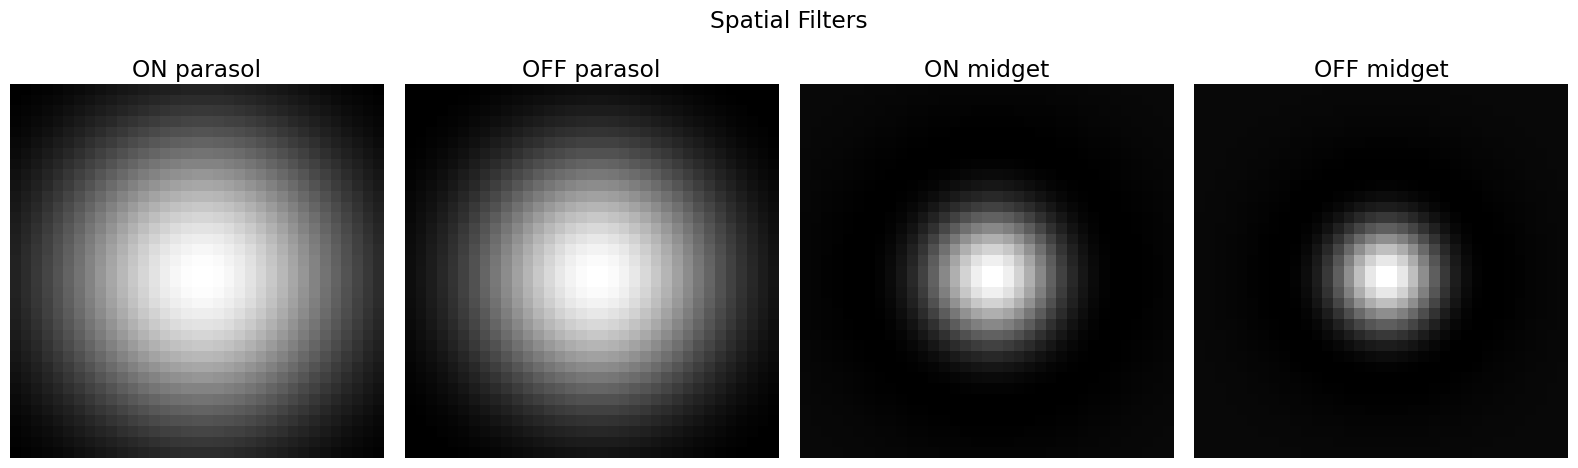

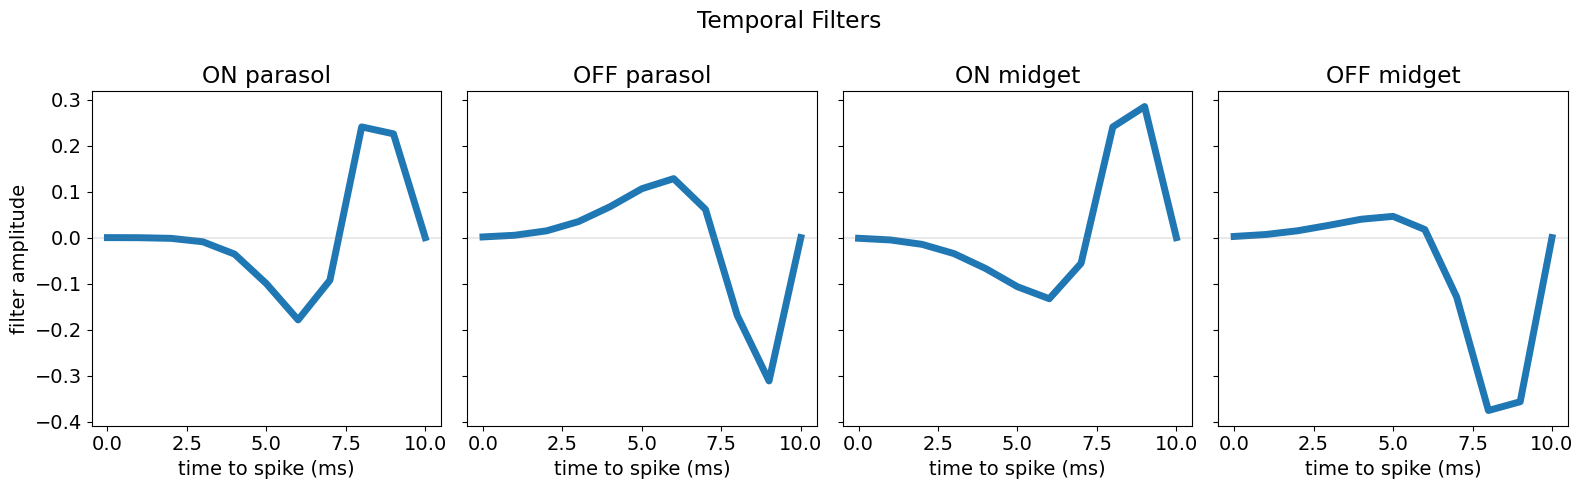

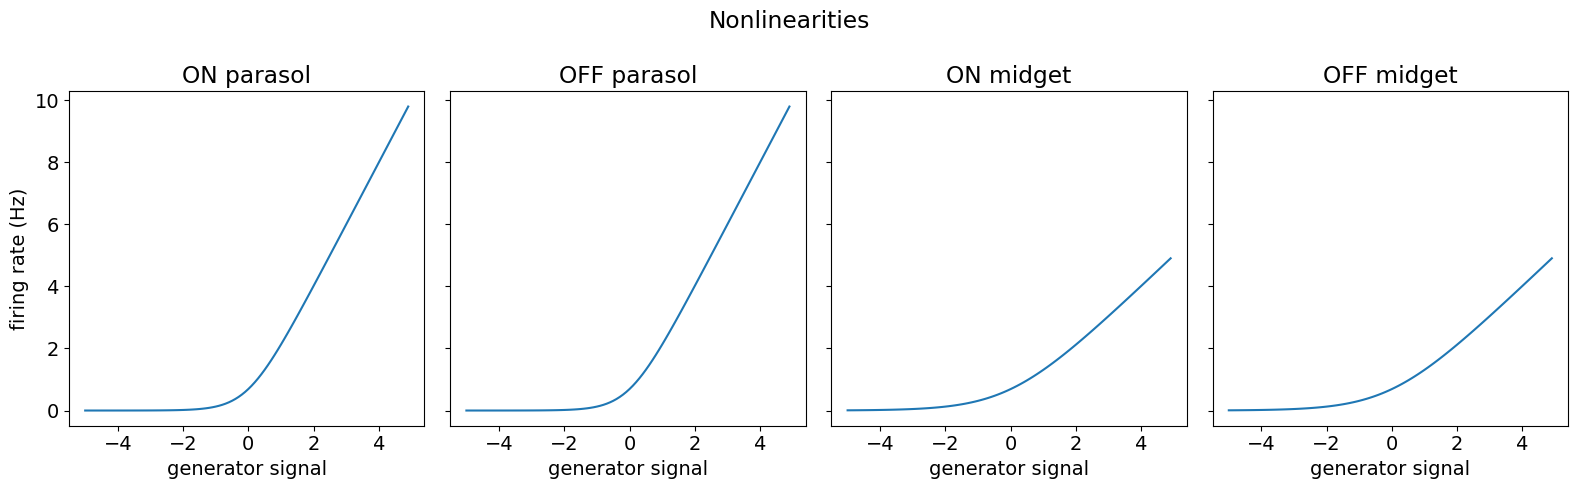

In [8]:
# plot the spatial filters
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

for i, (celltype,model) in enumerate(models.items()):

    ax[i].imshow(model.spatial_filter, cmap="gray") #, vmin=-1, vmax=1)
    ax[i].set_title(celltype)
    ax[i].axis("off")

fig.suptitle("Spatial Filters")

fig.set_tight_layout(True)
plt.show()

# plot the temporal filters
fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharex=True, sharey=True)

for i, (celltype,model) in enumerate(models.items()):

    ax[i].plot(model.temporal_filter, lw=5)
    ax[i].axhline(y=0, c="gray", lw=0.25)
    ax[i].set_title(celltype)
    ax[i].set_xlabel("time to spike (ms)")

fig.suptitle("Temporal Filters")
ax[0].set_ylabel("filter amplitude")

fig.set_tight_layout(True)
plt.show()

# plot the nonlinearities
fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharex=True, sharey=True)

for i, (celltype,model) in enumerate(models.items()):

    ax[i].plot(np.arange(-5, 5, 0.1), model.nonlinearity(torch.arange(-5, 5, 0.1)))
    ax[i].set_title(celltype)
    ax[i].set_xlabel("generator signal")

fig.suptitle("Nonlinearities")
ax[0].set_ylabel("firing rate (Hz)")

fig.set_tight_layout(True)
plt.show()

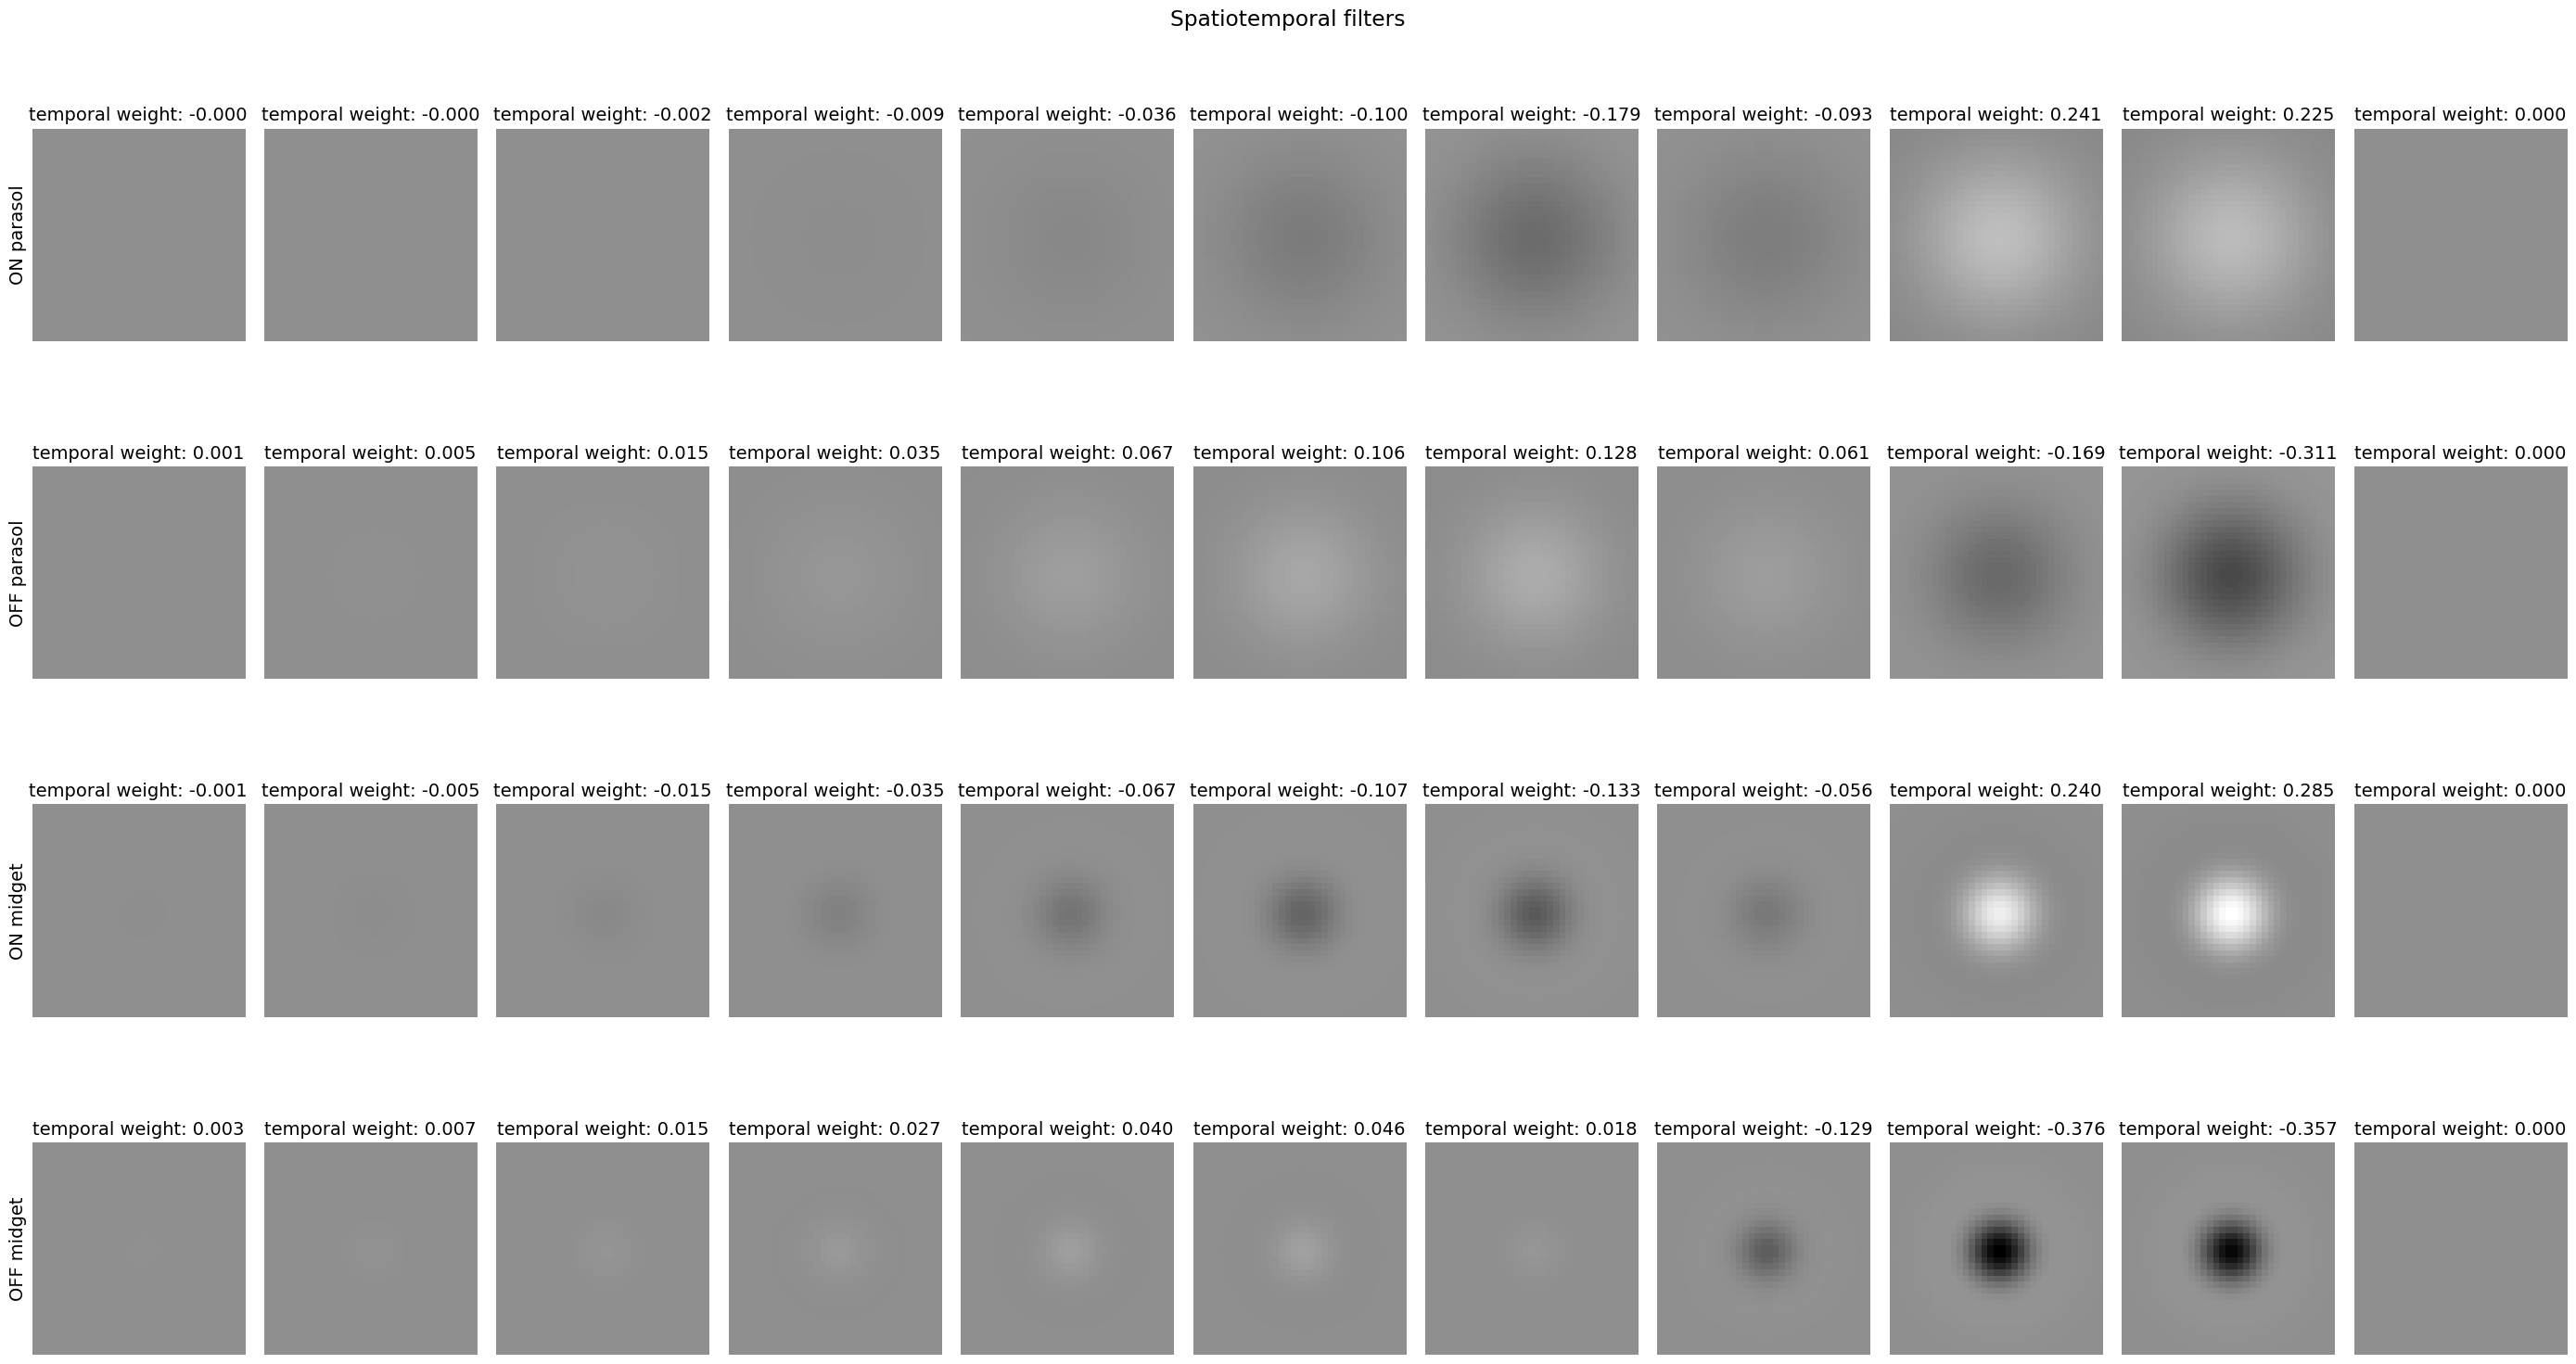

In [9]:
# combine the spatial and temporal filters to show what the combined information encodes
fig, ax = plt.subplots(4, models["ON midget"].temporal_filter.shape[0], figsize=(28, 16))

# compute min and max for comparisons
min_v, max_v = 0, 0
for celltype,model in models.items():
    if model.spatiotemporal_filter.min() < min_v:
        min_v = model.spatiotemporal_filter.min()
    if model.spatiotemporal_filter.max() > max_v:
        max_v = model.spatiotemporal_filter.max()

for i,(celltype,model) in enumerate(models.items()):

    for j,t in enumerate(model.temporal_filter):
        ax[i][j].imshow(model.spatiotemporal_filter[j], cmap="gray", vmin=min_v, vmax=max_v)
        ax[i][j].set_title(f"temporal weight: {t:.3f}", fontsize=14)

        # turning off the border
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
        ax[i][j].set_frame_on(False)

    ax[i][0].set_ylabel(celltype)

fig.suptitle("Spatiotemporal filters")
fig.set_tight_layout(True)
plt.show()

In [10]:
for model in models.values():
    print(torch.sum(model.temporal_filter))

tensor(0.0479)
tensor(-0.0616)
tensor(0.1067)
tensor(-0.7065)


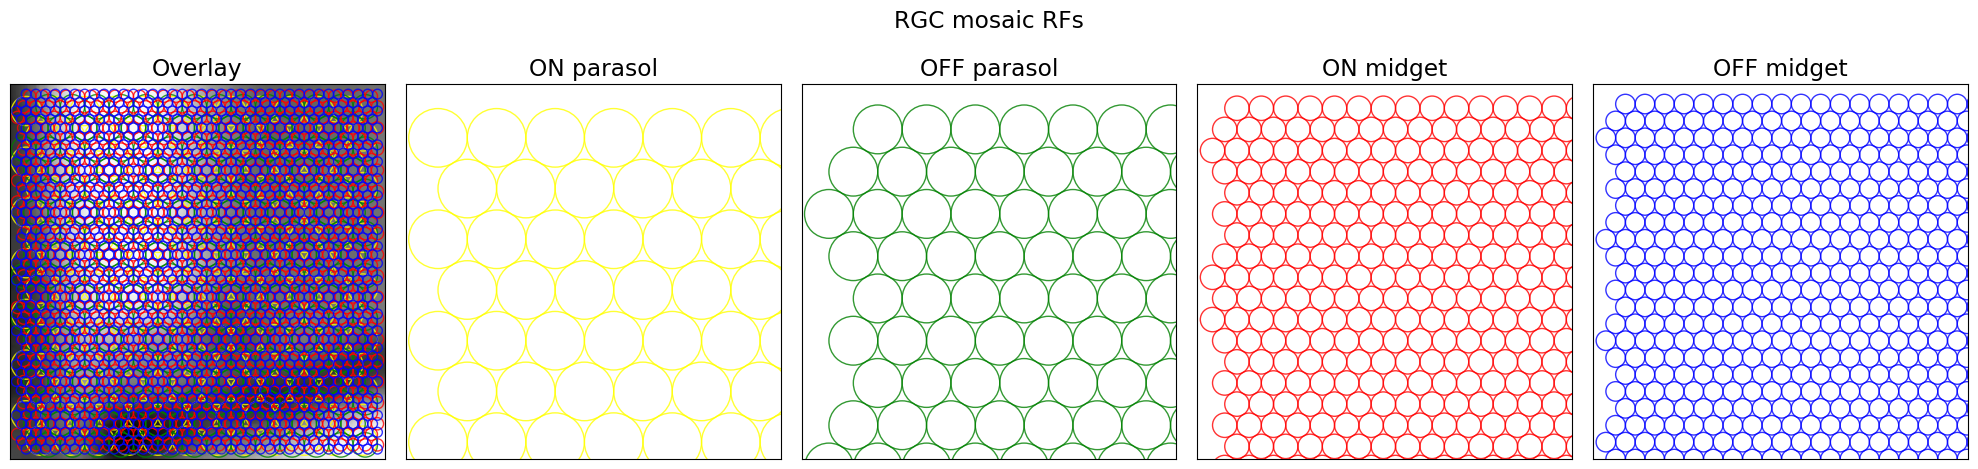

In [11]:
# now let's mosaic these, so we can see the multiple cell types
colors = ["blue", "red", "green", "yellow"]
colors.reverse()

fig, ax = plt.subplots(1, 5, figsize=(20, 5))
ax[0].imshow(video_patch[182], cmap="gray")

# plot on parasol RFs
for i,(celltype,model) in enumerate(models.items()):
    
    for x,y in model.mosaic:

        # make 2 mosaics bc of plt limitations
        joint_circle = patches.Circle((x, y), model.m_params["spatial"]["center_size"]/2, 
                                        linewidth=1, edgecolor=colors[i], 
                                        facecolor='none', alpha=0.8)
        ind_circle = patches.Circle((x, y), model.m_params["spatial"]["center_size"]/2, 
                                        linewidth=1, edgecolor=colors[i], 
                                        facecolor='none', alpha=0.8)

        # plot jointly
        ax[0].add_patch(joint_circle)

        # also add each cell type to an independent mosaic so we can observe them
        ax[i+1].imshow(np.ones(shape=(64,64)), cmap="gray", vmin=0, vmax=1)
        ax[i+1].add_patch(ind_circle)
        ax[i+1].set_title(celltype)
    
ax[0].set_title("Overlay")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

fig.suptitle("RGC mosaic RFs")
fig.set_tight_layout(True)
plt.show()

In [12]:
generator_signals = {}
firing_rates = {}
times = {}
counts = {}

for celltype,model in models.items():
    generator_signals[celltype], firing_rates[celltype] = model.forward(video_patch)
    times[celltype], counts[celltype] = model.spikes(firing_rates[celltype])

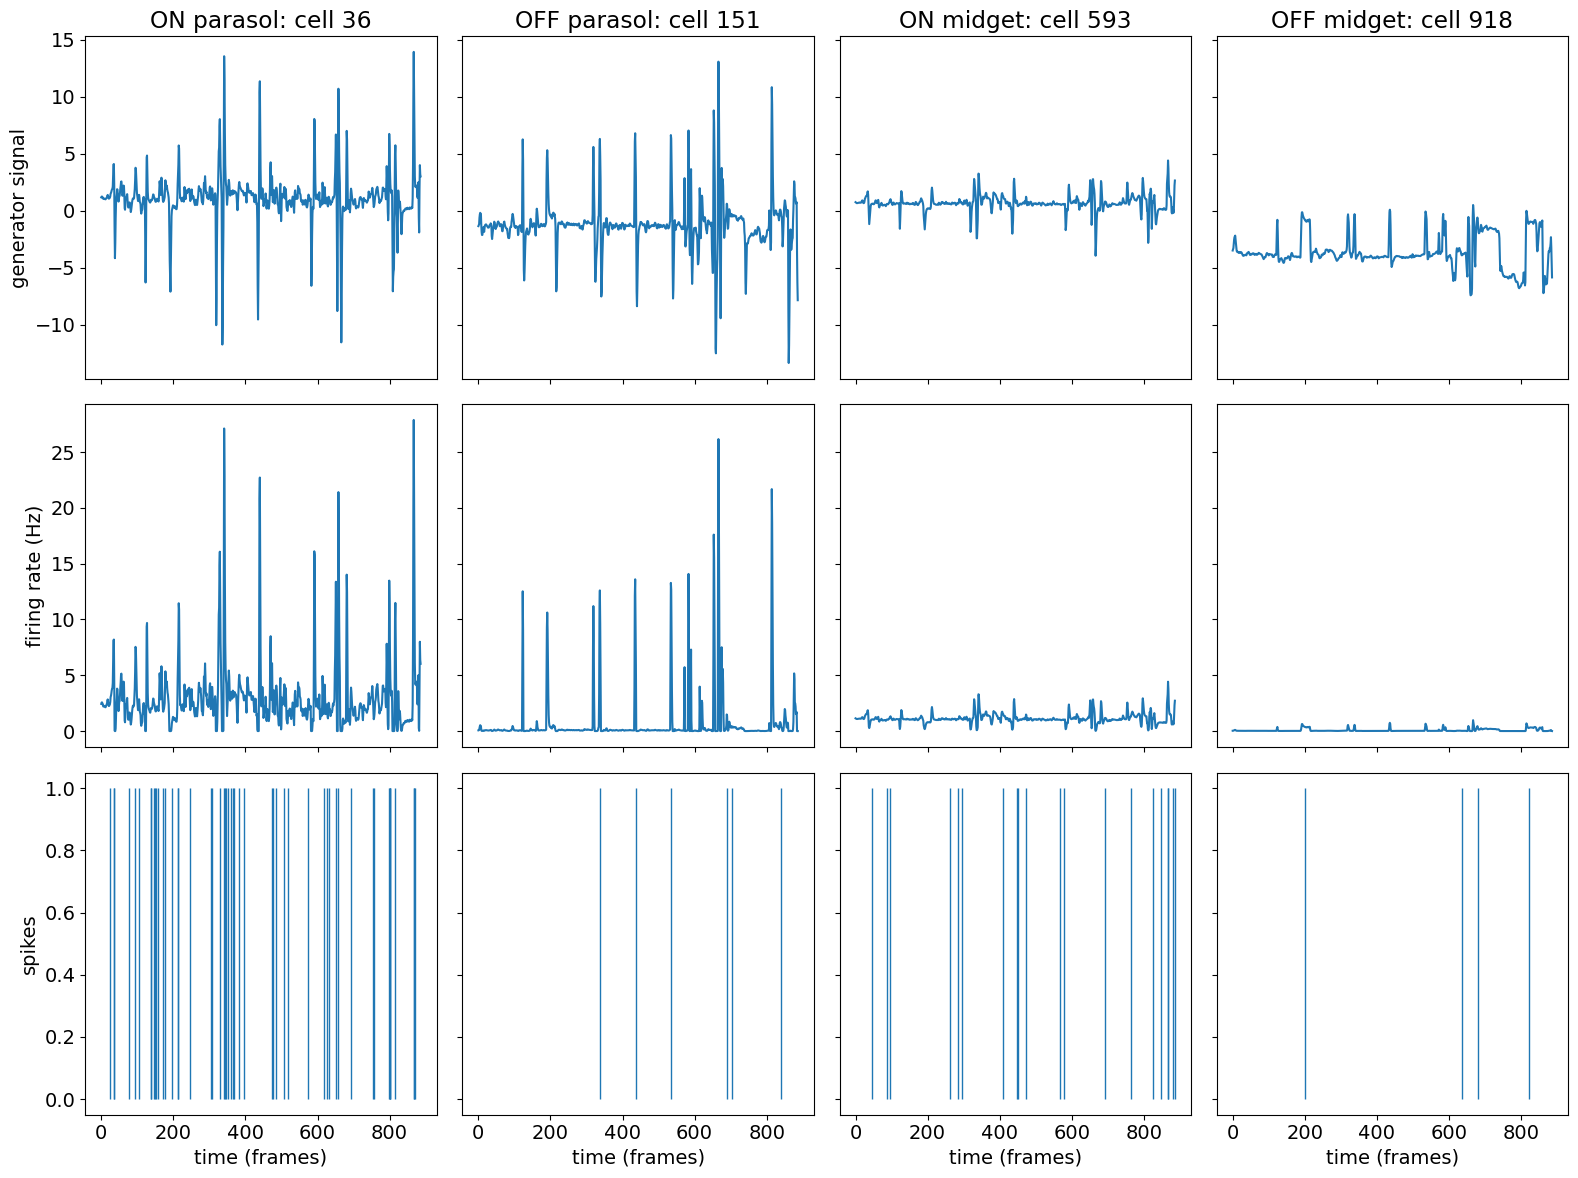

In [13]:
# plot the responses from one cell from each celltype group
fig, ax = plt.subplots(3, 4, figsize=(16, 12), sharex=True, sharey="row")

for j,celltype in enumerate(models.keys()):
    rand_cell = np.random.randint(0, generator_signals[celltype].shape[0])

    ax[0][j].plot(generator_signals[celltype][rand_cell])
    ax[1][j].plot(firing_rates[celltype][rand_cell])
    ax[2][j].vlines(np.arange(len(generator_signals[celltype][rand_cell]))[counts[celltype][rand_cell] == 1], 0, 1, lw=1)

    # set our axes titles/labels
    if j == 0:
        ax[0][j].set_ylabel("generator signal")
        ax[1][j].set_ylabel("firing rate (Hz)")
        ax[2][j].set_ylabel("spikes")
    ax[2][j].set_xlabel("time (frames)")

    # set titles
    ax[0][j].set_title(f"{celltype}: cell {rand_cell}")

fig.set_tight_layout(True)
plt.show()

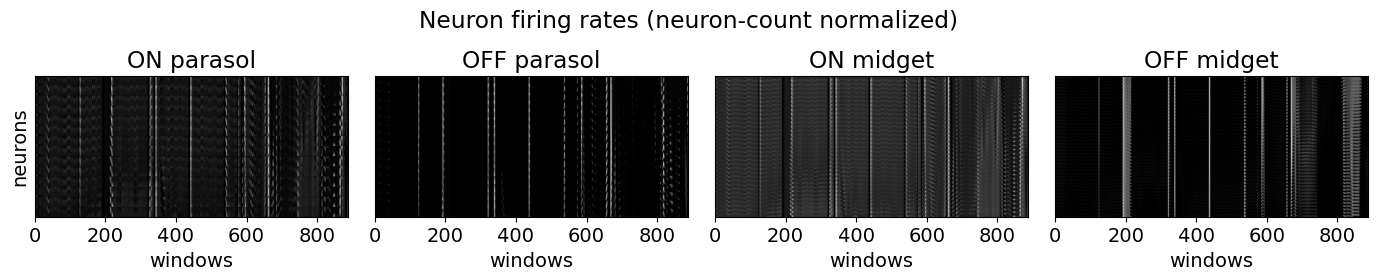

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(14, 2.5))

for i,celltype in enumerate(models.keys()):
    ax[i].imshow(firing_rates[celltype].numpy(), cmap="gray", aspect=400/models[celltype].n_cells)
    ax[i].set_title(celltype)
    ax[i].set_xlabel("windows")
    ax[i].set_yticks([])
    ax[0].set_ylabel("neurons")

fig.suptitle("Neuron firing rates (neuron-count normalized)")
fig.set_tight_layout(True)
plt.show()

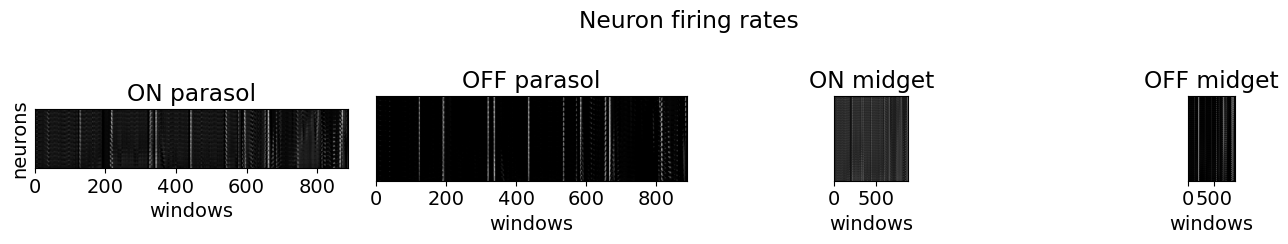

In [15]:
fig, ax = plt.subplots(1, 4, figsize=(14, 2.5))

for i,celltype in enumerate(models.keys()):
    ax[i].imshow(firing_rates[celltype].numpy(), cmap="gray")
    ax[i].set_title(celltype)
    ax[i].set_xlabel("windows")
    ax[i].set_yticks([])
    ax[0].set_ylabel("neurons")

fig.suptitle("Neuron firing rates")
fig.set_tight_layout(True)
plt.show()

## Retina

Let's test my retina class to make sure it produces outputs we expect

In [16]:
retina = Retina(model_parameters=all_params, video_parameters=video_params)

In [26]:
linear, activations = retina.forward(video_patch)

In [27]:
activations.shape

torch.Size([5, 1601, 887])

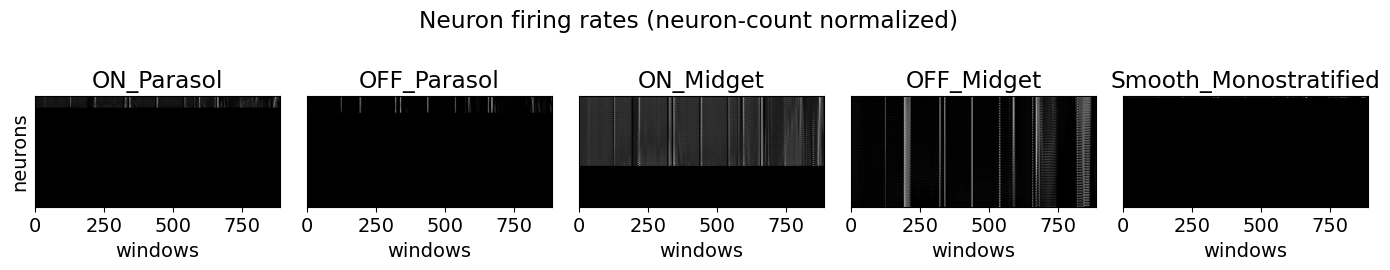

In [30]:
fig, ax = plt.subplots(1, 5, figsize=(14, 2.5))
celltypes = ["ON_Parasol", "OFF_Parasol", "ON_Midget", "OFF_Midget", "Smooth_Monostratified"]

for i,(c_act,type) in enumerate(zip(activations, celltypes)):
    ax[i].imshow(c_act, cmap="gray", aspect=400/models[celltype].n_cells)
    ax[i].set_title(type)
    ax[i].set_xlabel("windows")
    ax[i].set_yticks([])
    ax[0].set_ylabel("neurons")

fig.suptitle("Neuron firing rates (neuron-count normalized)")
fig.set_tight_layout(True)
plt.show()

## Smooth monostratified cells
Now, let's test the newly created smooth monostratified cells

In [31]:
from sk_retina_encoders import SmoothMonostratifiedCellMosaic

sm_params = all_params["ON_Smooth_Monostratified"]
sm_model = SmoothMonostratifiedCellMosaic(
    model_parameters=sm_params, 
    video_parameters=video_params
)
print(f"Cell type: {sm_params['cell_type']}")
print(f"Number of cells in mosaic: {sm_model.n_cells}")
print(f"Number of subunits: {sm_model.n_subunits}")
print(f"RF diameter: {sm_model.rf_diam}")
print(f"Spatiotemporal filter shape: {sm_model.spatiotemporal_filter.shape}")

Cell type: ON_Smooth_Monostratified
Number of cells in mosaic: 23
Number of subunits: 4
RF diameter: 85
Spatiotemporal filter shape: torch.Size([4, 11, 85, 85])


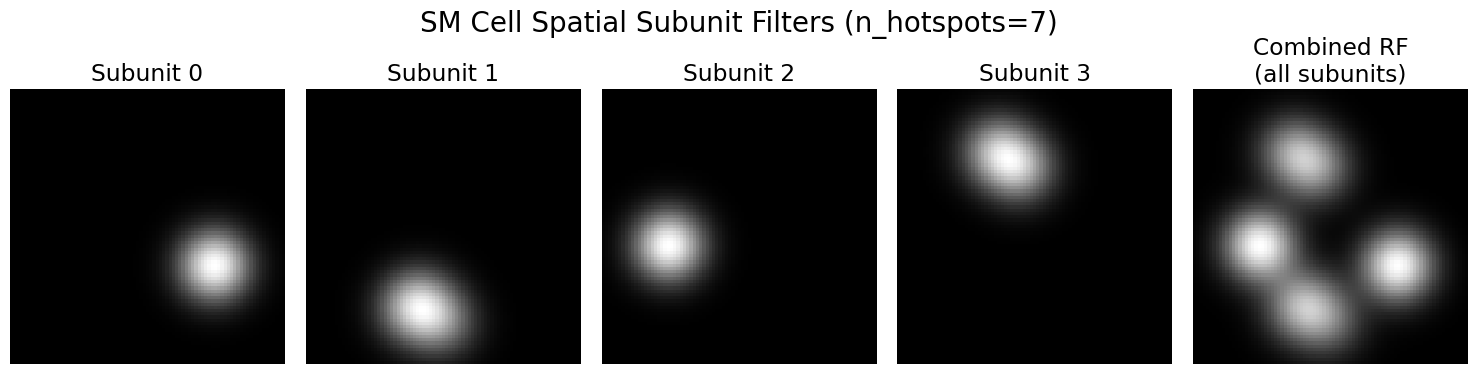

In [35]:
n_sub = sm_model.n_subunits
fig, axes = plt.subplots(1, n_sub+1, figsize=(3 * (n_sub+1), 4))

# Plot individual subunit spatial filters
for i in range(n_sub):
    ax = axes[i]
    sf = sm_model.spatial_filter[i].numpy()
    ax.imshow(sf, cmap="gray")
    ax.set_title(f"Subunit {i}")
    ax.axis("off")

# Plot the combined (summed) spatial filter
combined = sm_model.spatial_filter.sum(dim=0).numpy()
axes[-1].imshow(combined, cmap="gray")
axes[-1].set_title("Combined RF\n(all subunits)")
axes[-1].axis("off")

fig.suptitle(f"SM Cell Spatial Subunit Filters (n_hotspots={sm_params['n_hotspots']})", fontsize=20)
fig.set_tight_layout(True)
plt.show()


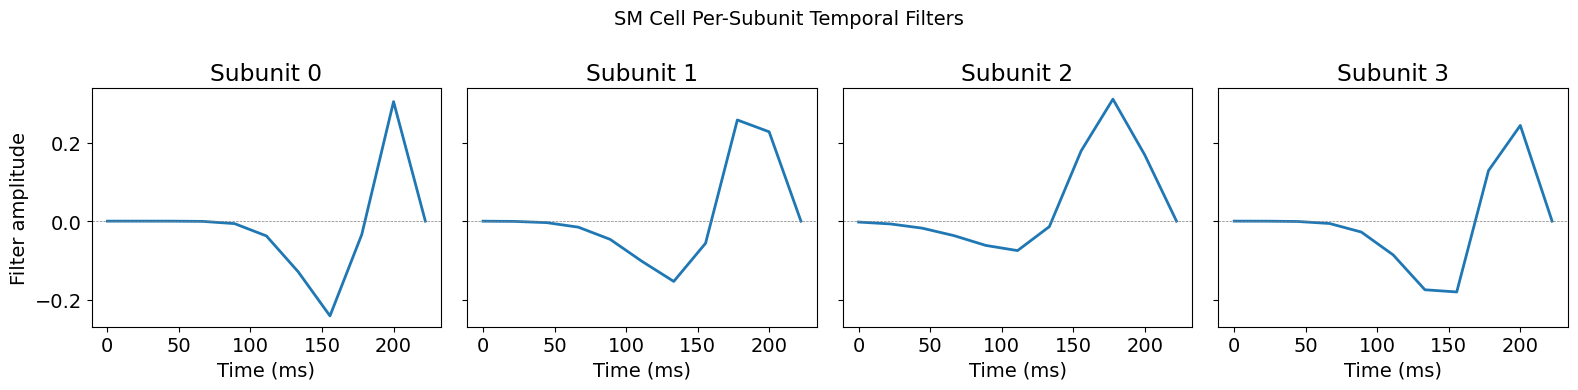

In [36]:
fig, axes = plt.subplots(1, n_sub, figsize=(4 * n_sub, 4), sharex=True, sharey=True)

dt_ms = 1000. / video_params["frame_rate"]
for i in range(n_sub):
    ax = axes[i]
    tf = sm_model.temporal_filter[i].numpy()
    t_axis = np.arange(len(tf)) * dt_ms
    ax.plot(t_axis, tf, lw=2)
    ax.axhline(y=0, c="gray", lw=0.5, ls="--")
    ax.set_title(f"Subunit {i}")
    ax.set_xlabel("Time (ms)")

axes[0].set_ylabel("Filter amplitude")
fig.suptitle("SM Cell Per-Subunit Temporal Filters", fontsize=14)
fig.set_tight_layout(True)
plt.show()


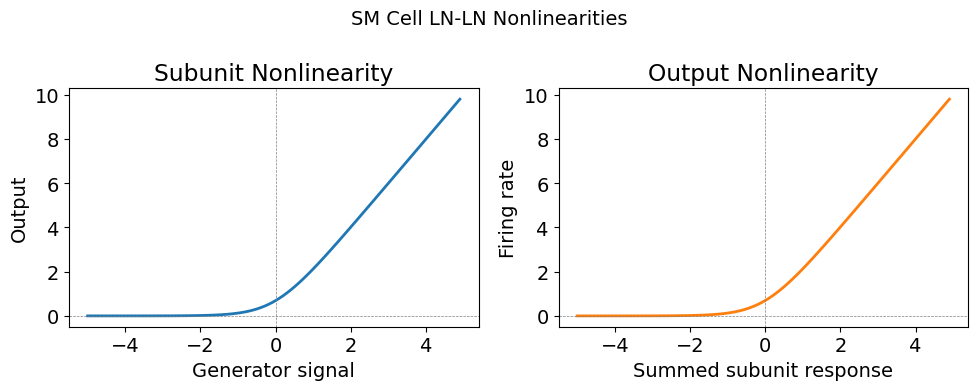

In [37]:
x_range = torch.arange(-5, 5, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Subunit nonlinearity
axes[0].plot(x_range.numpy(), sm_model.subunit_nonlinearity(x_range).numpy(), lw=2, label="Subunit NL")
axes[0].set_title("Subunit Nonlinearity")
axes[0].set_xlabel("Generator signal")
axes[0].set_ylabel("Output")
axes[0].axhline(y=0, c="gray", lw=0.5, ls="--")
axes[0].axvline(x=0, c="gray", lw=0.5, ls="--")

# Output nonlinearity
axes[1].plot(x_range.numpy(), sm_model.nonlinearity(x_range).numpy(), lw=2, color="tab:orange", label="Output NL")
axes[1].set_title("Output Nonlinearity")
axes[1].set_xlabel("Summed subunit response")
axes[1].set_ylabel("Firing rate")
axes[1].axhline(y=0, c="gray", lw=0.5, ls="--")
axes[1].axvline(x=0, c="gray", lw=0.5, ls="--")

fig.suptitle("SM Cell LN-LN Nonlinearities", fontsize=14)
fig.set_tight_layout(True)
plt.show()


In [38]:
# Forward pass through the SM model
sm_linear, sm_rate = sm_model.forward(video_patch)
print(f"SM linear response shape: {sm_linear.shape}")
print(f"SM firing rate shape: {sm_rate.shape}")
print(f"SM firing rate range: [{sm_rate.min().item():.4f}, {sm_rate.max().item():.4f}]")
print(f"SM firing rate mean: {sm_rate.mean().item():.4f}")

SM linear response shape: torch.Size([23, 887])
SM firing rate shape: torch.Size([23, 887])
SM firing rate range: [0.6932, 700.0000]
SM firing rate mean: 95.0957


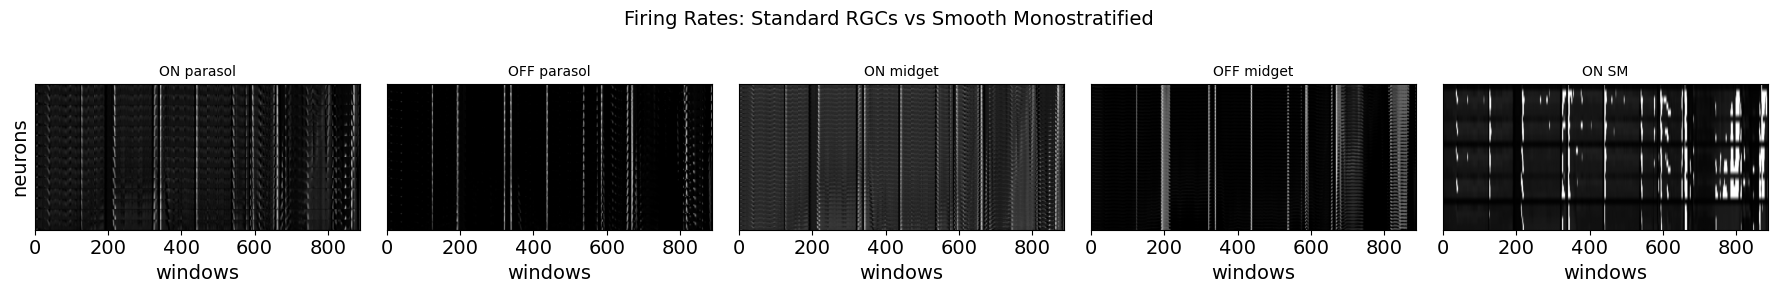

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))

# Plot the 4 standard RGC types
for i, celltype in enumerate(models.keys()):
    axes[i].imshow(firing_rates[celltype].numpy(), cmap="gray", aspect="auto")
    axes[i].set_title(celltype, fontsize=10)
    axes[i].set_xlabel("windows")
    axes[i].set_yticks([])

# Plot SM cells
axes[4].imshow(sm_rate.detach().numpy(), cmap="gray", aspect="auto")
axes[4].set_title("ON SM", fontsize=10)
axes[4].set_xlabel("windows")
axes[4].set_yticks([])

axes[0].set_ylabel("neurons")
fig.suptitle("Firing Rates: Standard RGCs vs Smooth Monostratified", fontsize=14)
fig.set_tight_layout(True)
plt.show()


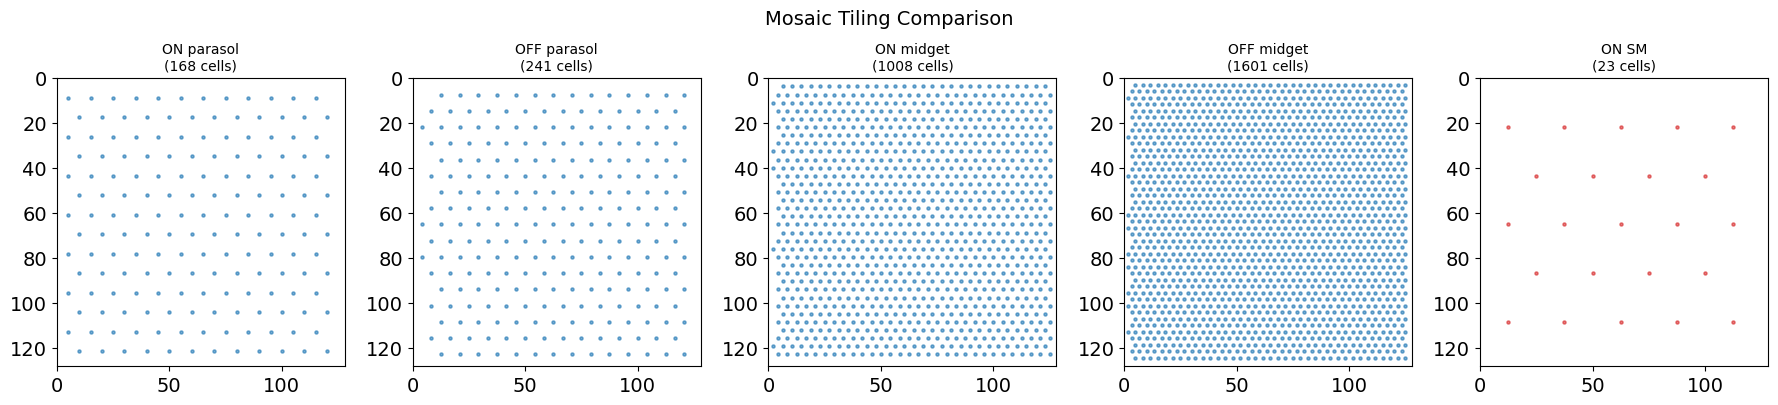

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Standard RGC mosaics
for i, (celltype, model) in enumerate(models.items()):
    mosaic = model.mosaic.numpy()
    axes[i].scatter(mosaic[:, 0], mosaic[:, 1], s=5, alpha=0.6)
    axes[i].set_title(f"{celltype}\n({model.n_cells} cells)", fontsize=10)
    axes[i].set_xlim(0, video_params["frame_shape"][1])
    axes[i].set_ylim(0, video_params["frame_shape"][0])
    axes[i].set_aspect("equal")
    axes[i].invert_yaxis()

# SM mosaic
sm_mosaic = sm_model.mosaic_tensor.numpy()
axes[4].scatter(sm_mosaic[:, 0], sm_mosaic[:, 1], s=5, alpha=0.6, color="tab:red")
axes[4].set_title(f"ON SM\n({sm_model.n_cells} cells)", fontsize=10)
axes[4].set_xlim(0, video_params["frame_shape"][1])
axes[4].set_ylim(0, video_params["frame_shape"][0])
axes[4].set_aspect("equal")
axes[4].invert_yaxis()

fig.suptitle("Mosaic Tiling Comparison", fontsize=14)
fig.set_tight_layout(True)
plt.show()

Total spikes across all SM cells: 43279
Cells with at least one spike: 23/23
Spike count tensor shape: torch.Size([23, 887])
Mean spikes per cell: 2.1214


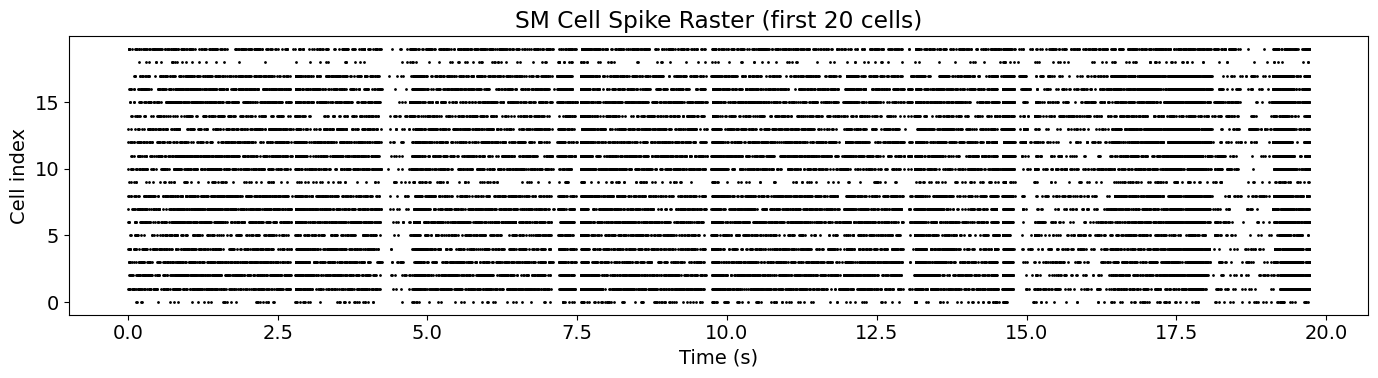

In [41]:
sm_spike_times, sm_spike_counts = sm_model.spikes(sm_rate)

# Summary statistics
total_spikes = sum(len(t) for t in sm_spike_times)
cells_with_spikes = sum(1 for t in sm_spike_times if len(t) > 0)

print(f"Total spikes across all SM cells: {total_spikes}")
print(f"Cells with at least one spike: {cells_with_spikes}/{sm_model.n_cells}")
print(f"Spike count tensor shape: {sm_spike_counts.shape}")
print(f"Mean spikes per cell: {sm_spike_counts.float().mean().item():.4f}")

# Raster plot for a subset of cells
n_plot = min(20, sm_model.n_cells)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
for i in range(n_plot):
    times = sm_spike_times[i]
    if len(times) > 0:
        ax.scatter(times, np.full_like(times, i), s=1, c="black")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Cell index")
ax.set_title(f"SM Cell Spike Raster (first {n_plot} cells)")
fig.set_tight_layout(True)
plt.show()